# 2. Logistic Regression Baseline

First full-data Logistic Regression fit: stratified 80/20 split, `class_weight='balanced'`, confusion matrix, overall metrics, and coefficient interpretation.

In [1]:
import sys
from pathlib import Path

# Find the project root regardless of what VS Code / Jupyter set as the
# working directory (VS Code defaults notebooks to the workspace root,
# not the notebook's own folder, so ".." alone isn't reliable).
cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    recall_score,
)

from src.models import get_logistic_regression
from src.preprocessing import build_logreg_pipeline, load_data, stratified_split

df = load_data()


## 2.1 Model fit

In [2]:
X_train, X_test, y_train, y_test = stratified_split(df)

print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))

pipe = build_logreg_pipeline(get_logistic_regression())
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred))


Train class balance:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Test class balance:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64


              precision    recall  f1-score   support

     Dropout       0.81      0.69      0.75       284
    Enrolled       0.41      0.62      0.49       159
    Graduate       0.86      0.78      0.82       442

    accuracy                           0.72       885
   macro avg       0.69      0.70      0.69       885
weighted avg       0.76      0.72      0.74       885



## 2.2 Confusion matrix

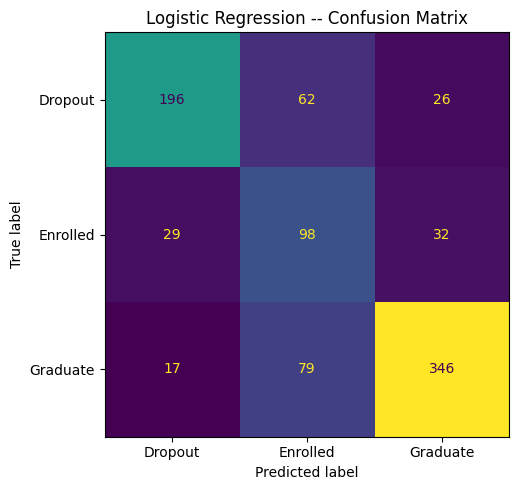

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Logistic Regression -- Confusion Matrix")
plt.tight_layout()
plt.show()


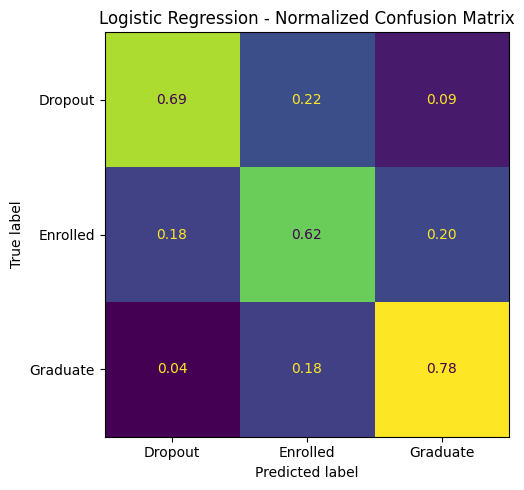

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="true", values_format=".2f", colorbar=False, ax=ax
)
ax.set_title("Logistic Regression - Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


## 2.3 Overall performance metrics

In [5]:
logreg_accuracy = accuracy_score(y_test, y_pred)
logreg_macro_f1 = f1_score(y_test, y_pred, average="macro")
logreg_weighted_f1 = f1_score(y_test, y_pred, average="weighted")
logreg_macro_recall = recall_score(y_test, y_pred, average="macro")

print(f"Accuracy:     {logreg_accuracy:.3f}")
print(f"Macro F1:     {logreg_macro_f1:.3f}")
print(f"Weighted F1:  {logreg_weighted_f1:.3f}")
print(f"Macro Recall: {logreg_macro_recall:.3f}")


Accuracy:     0.723
Macro F1:     0.685
Weighted F1:  0.736
Macro Recall: 0.696


## 2.4 Coefficient interpretation

In [6]:
preprocessor = pipe.named_steps["preprocess"]
logreg_model = pipe.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame(
    logreg_model.coef_, columns=feature_names, index=logreg_model.classes_
)
coef_df.head()


,num__Application order,num__Age at enrollment,num__Curricular units 1st sem (credited),num__Curricular units 1st sem (enrolled),num__Curricular units 1st sem (evaluations),num__Curricular units 1st sem (approved),num__Curricular units 1st sem (grade),num__Curricular units 1st sem (without evaluations),num__Curricular units 2nd sem (credited),num__Curricular units 2nd sem (enrolled),...,cat__Father's occupation_45,cat__Father's occupation_46,bin__Daytime/evening attendance,bin__Displaced,bin__Educational special needs,bin__Debtor,bin__Tuition fees up to date,bin__Gender,bin__Scholarship holder,bin__International
Dropout,0.129472,0.112860,0.153486,0.303383,-0.037158,-0.863032,0.073770,-0.081049,0.300656,0.954889,...,0.046976,-0.005209,0.152739,0.226651,0.088649,0.425820,-1.821728,0.215390,-0.180744,-0.184959
Enrolled,-0.122893,-0.004446,-0.031702,0.257467,0.205088,-0.433444,-0.099281,0.059075,-0.233648,0.212911,...,-0.428114,-0.195000,-0.061852,-0.107500,0.015132,0.281862,0.248170,-0.089458,-0.291453,0.183231
Graduate,-0.006579,-0.108414,-0.121784,-0.560849,-0.167930,1.296477,0.025510,0.021974,-0.067007,-1.167800,...,0.381138,0.200209,-0.090888,-0.119150,-0.103781,-0.707682,1.573559,-0.125933,0.472197,0.001728


In [7]:
dropout_coef = coef_df.loc["Dropout"].sort_values()

print("Most negative coefficients:")
display(dropout_coef.head(10))

print("\nMost positive coefficients:")
display(dropout_coef.tail(10))


Most negative coefficients:


bin__Tuition fees up to date               -1.821728
num__Curricular units 2nd sem (approved)   -1.657516
cat__Mother's occupation_29                -1.240486
cat__Nacionality_11                        -0.980761
num__Curricular units 1st sem (approved)   -0.863032
cat__Course_2                              -0.810490
cat__Mother's qualification_4              -0.800037
cat__Application mode_6                    -0.784538
cat__Father's occupation_35                -0.639681
cat__Application mode_17                   -0.614983
Name: Dropout, dtype: float64


Most positive coefficients:


cat__Mother's occupation_9                  0.689231
cat__Father's qualification_30              0.734439
cat__Previous qualification_4               0.743423
cat__Previous qualification_2               0.774903
cat__Course_16                              0.840396
cat__Course_8                               0.853895
cat__Mother's occupation_12                 0.873045
num__Curricular units 2nd sem (enrolled)    0.954889
cat__Father's occupation_12                 1.167572
cat__Mother's occupation_1                  1.254176
Name: Dropout, dtype: float64

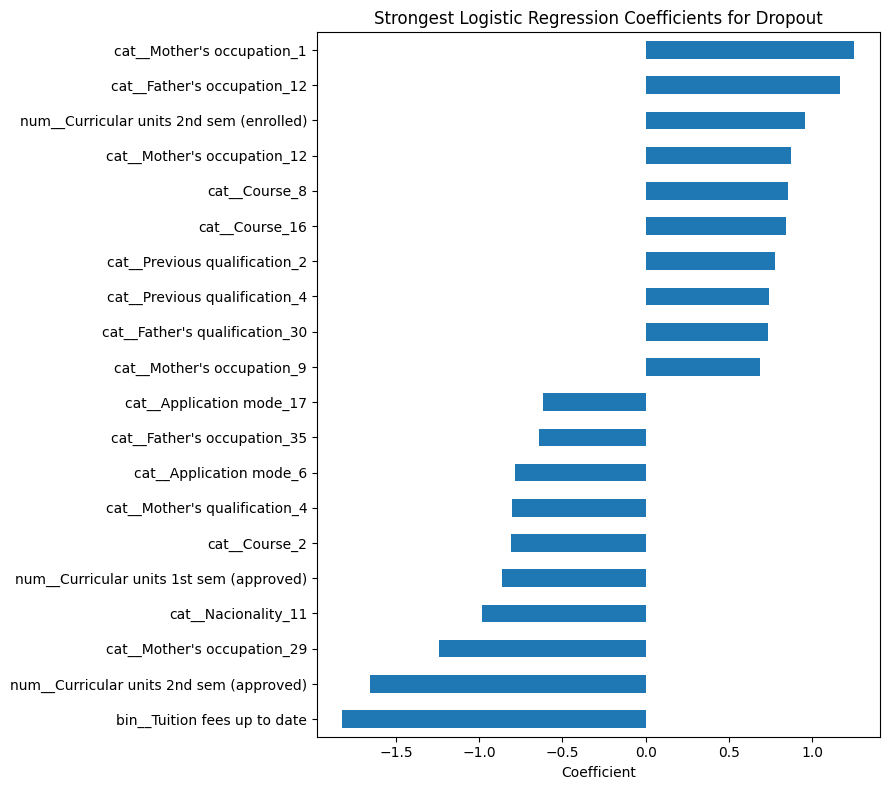

In [8]:
top_dropout_coef = pd.concat([dropout_coef.head(10), dropout_coef.tail(10)]).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
top_dropout_coef.plot(kind="barh", ax=ax)
ax.set_title("Strongest Logistic Regression Coefficients for Dropout")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.show()
